# Change github.com to githubtocolab.com to open colab 

In [ ]:
import os

!git clone https://github.com/cegranger/craps-ai.git

os.chdir("craps-ai")

!git checkout notebook-opencv
# !pip install -r requirements.txt


# Génération d'un ensemble de données pour entrainer ton IA

In [ ]:
from dice_detection import run_dice_detection
run_dice_detection()

# Est-ce que c'est bien ça ? 

Found 272 files belonging to 6 classes.
Using 218 files for training.


Using 54 files for validation.


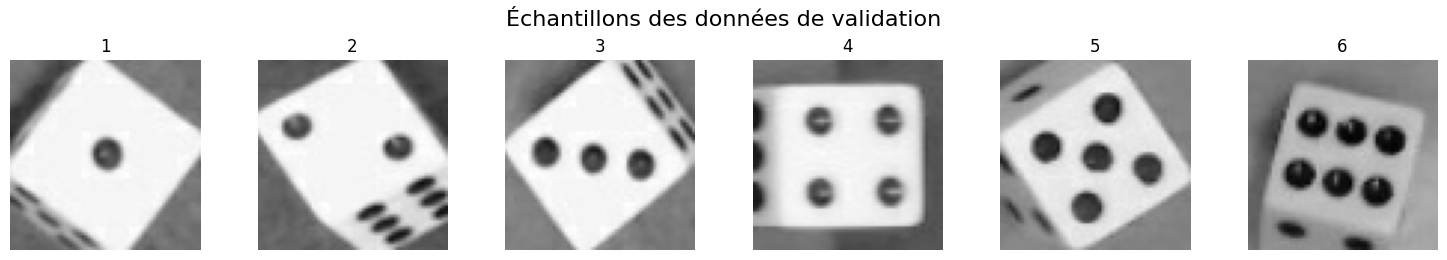

None


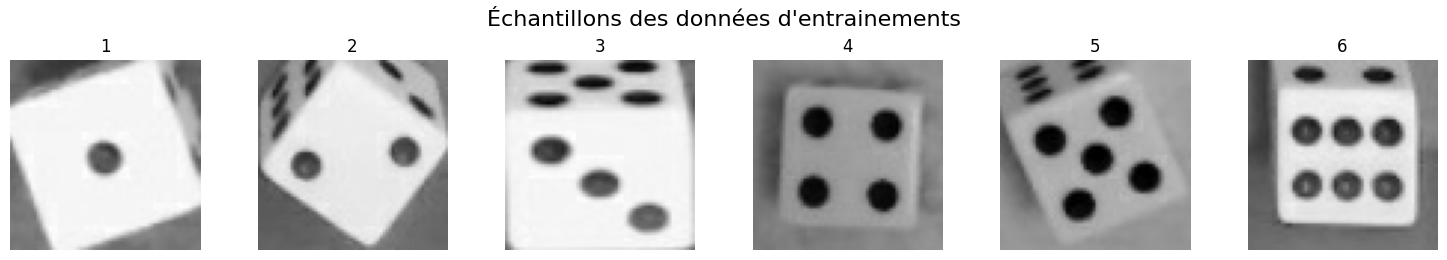

None


In [4]:
import matplotlib.pyplot as plt
from datasets.dataset import Dataset

# affiche les données de validation 0 et d'entrainement 1
data = Dataset()
print(data.plot_classes(0)) 
print(data.plot_classes(1))


# Crée un réseau de neurone convolutionnel ! 

In [ ]:
import plotly.graph_objects as go
import numpy as np
import tensorflow as tf
from tensorflow import keras

def create_centered_layer(x_offset, width, height, depth, color, opacity=0.7, name="Layer"):
    """Create a 3D representation of a CNN layer centered at origin"""
    # Center the layer at y=0, z=0
    y_start = -width / 2
    z_start = -height / 2
    
    x = np.array([0, depth, depth, 0, 0, depth, depth, 0]) + x_offset
    y = np.array([0, 0, width, width, 0, 0, width, width]) + y_start
    z = np.array([0, 0, 0, 0, height, height, height, height]) + z_start
    
    i = [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 0, 1, 2, 3]
    j = [1, 2, 2, 3, 3, 0, 0, 4, 5, 6, 6, 7, 7, 4, 4, 5, 4, 5, 6, 7]
    k = [2, 3, 3, 0, 0, 1, 4, 5, 6, 7, 7, 4, 4, 5, 5, 6, 5, 6, 7, 4]
    
    return go.Mesh3d(
        x=x, y=y, z=z,
        i=i, j=j, k=k,
        color=color,
        opacity=opacity,
        name=name,
        showlegend=True,
        hovertemplate=f'{name}<br>Shape: {int(width)}x{int(height)}x{int(depth)}<extra></extra>'
    )

def create_centered_feature_maps(x_offset, num_maps, map_size, spacing=0.5, color='blue', name="Feature Maps"):
    """Create multiple feature maps centered at origin"""
    traces = []
    total_depth = num_maps * spacing
    start_offset = -total_depth / 2
    
    for i in range(min(num_maps, 32)):  # Limit to 32 for performance
        depth_offset = start_offset + i * spacing
        trace = create_centered_layer(
            x_offset + depth_offset, 
            map_size, 
            map_size, 
            spacing * 0.8,  # Make each slice thinner than spacing
            color,
            opacity=0.6,
            name=f"{name}_{i}"
        )
        trace.showlegend = (i == 0)
        traces.append(trace)
    return traces

def parse_keras_model(model):
    """Parse a Keras model and extract layer information"""
    layers_info = []
    x_offset = 0
    spacing = 10  # Space between different layer types
    
    for layer in model.layers:
        layer_type = layer.__class__.__name__
        
        if hasattr(layer, 'input_shape') and layer.input_shape:
            if layer == model.layers[0]:  # First layer - add input
                input_shape = layer.input_shape
                if len(input_shape) == 4:  # Batch dimension included
                    input_shape = input_shape[1:]
                elif len(input_shape) == 3:  # No batch dimension
                    pass
                else:  # Flatten input
                    input_shape = (input_shape[-1], 1, 1)
                
                layers_info.append({
                    'name': 'Input',
                    'type': 'input',
                    'shape': input_shape,
                    'x_offset': x_offset,
                    'color': 'lightblue'
                })
                x_offset += spacing
        
        # Get output shape
        output_shape = layer.output_shape
        if len(output_shape) == 4:  # Conv2D, MaxPooling2D etc.
            _, h, w, c = output_shape
            shape = (h, w, c)
        elif len(output_shape) == 2:  # Dense layer
            _, units = output_shape
            # Visualize dense layers as thin vertical rectangles
            shape = (int(np.sqrt(units)), int(np.sqrt(units)), 1)
        else:
            continue
        
        # Determine layer color based on type
        if 'Conv2D' in layer_type:
            color = 'blue'
        elif 'MaxPooling' in layer_type or 'Pooling' in layer_type:
            color = 'green'
        elif 'Dense' in layer_type:
            color = 'red' if layer != model.layers[-1] else 'gold'
        elif 'Dropout' in layer_type:
            continue  # Skip dropout layers in visualization
        elif 'Flatten' in layer_type:
            color = 'purple'
        else:
            color = 'gray'
        
        layers_info.append({
            'name': f'{layer.name}',
            'type': layer_type,
            'shape': shape,
            'x_offset': x_offset,
            'color': color
        })
        x_offset += spacing
    
    return layers_info

def visualize_model(model, title="CNN Architecture Visualization"):
    """
    Visualize any Keras/TensorFlow model in 3D
    
    Parameters:
    -----------
    model : tf.keras.Model
        A compiled or uncompiled Keras model
    title : str
        Title for the visualization
    """
    fig = go.Figure()
    layers_info = parse_keras_model(model)
    
    # Normalize sizes for better visualization
    max_size = max([max(info['shape'][:2]) for info in layers_info])
    scale_factor = 30 / max_size  # Scale largest dimension to 30 units
    
    for info in layers_info:
        h, w, c = info['shape']
        h_scaled = h * scale_factor
        w_scaled = w * scale_factor
        
        if info['type'] in ['Conv2D', 'MaxPooling2D', 'AveragePooling2D']:
            # For conv and pooling layers, show multiple feature maps
            traces = create_centered_feature_maps(
                info['x_offset'], 
                min(c, 32),  # Limit number of displayed channels
                max(h_scaled, w_scaled),
                spacing=0.5 if c > 16 else 1.0,
                color=info['color'],
                name=f"{info['name']} ({h}x{w}x{c})"
            )
            for trace in traces:
                fig.add_trace(trace)
        else:
            # For other layers, show as single block
            layer_trace = create_centered_layer(
                info['x_offset'],
                w_scaled,
                h_scaled,
                max(1, c * 0.1),  # Depth proportional to channels
                info['color'],
                name=f"{info['name']} ({h}x{w}x{c})" if c > 1 else f"{info['name']} ({h*w})"
            )
            fig.add_trace(layer_trace)
    
    # Add flow lines between layers
    connection_points = []
    for info in layers_info:
        connection_points.append([info['x_offset'] + 2, 0, 0])
    
    if len(connection_points) > 1:
        connections = np.array(connection_points)
        fig.add_trace(go.Scatter3d(
            x=connections[:, 0],
            y=connections[:, 1],
            z=connections[:, 2],
            mode='lines',
            line=dict(color='gray', width=3),
            opacity=0.3,
            showlegend=False,
            hoverinfo='skip'
        ))
    
    # Update layout
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(title='Network Depth →', showgrid=False, showticklabels=False),
            yaxis=dict(title='Width', showgrid=False, showticklabels=False),
            zaxis=dict(title='Height', showgrid=False, showticklabels=False),
            camera=dict(
                eye=dict(x=1.5, y=-1.5, z=0.8),
                center=dict(x=0, y=0, z=0)
            ),
            aspectmode='manual',
            aspectratio=dict(x=2.5, y=1, z=1)
        ),
        width=1200,
        height=600,
        showlegend=True,
        legend=dict(x=0.7, y=1, itemsizing='constant')
    )
    
    return fig

# Example usage with different models:

# Example 1: Simple CNN for MNIST
def create_simple_cnn():
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
        keras.layers.MaxPooling2D((2, 2), name='pool1'),
        keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        keras.layers.MaxPooling2D((2, 2), name='pool2'),
        keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),
        keras.layers.Flatten(name='flatten'),
        keras.layers.Dense(64, activation='relu', name='fc1'),
        keras.layers.Dense(10, activation='softmax', name='output')
    ])
    return model

# Example 2: VGG-like architecture
def create_vgg_like():
    model = keras.Sequential([
        # Block 1
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), name='block1_conv1'),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2'),
        keras.layers.MaxPooling2D((2, 2), name='block1_pool'),
        
        # Block 2
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1'),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2'),
        keras.layers.MaxPooling2D((2, 2), name='block2_pool'),
        
        # Block 3
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1'),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2'),
        keras.layers.MaxPooling2D((2, 2), name='block3_pool'),
        
        # FC layers
        keras.layers.Flatten(name='flatten'),
        keras.layers.Dense(512, activation='relu', name='fc1'),
        keras.layers.Dense(512, activation='relu', name='fc2'),
        keras.layers.Dense(10, activation='softmax', name='output')
    ])
    return model

# Create and visualize a model
# model = create_simple_cnn()
# fig = visualize_model(model, title="Custom CNN Architecture - Centered Visualization")
# fig.show()

# You can also pass your own model:
# your_model = keras.models.load_model('path_to_your_model.h5')
fig = visualize_model(model, title="My Model Architecture")
fig.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'path_to_your_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=data.input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')  # Output layer for 6 classes
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,974 (2.61 MB)

 Trainable params: 683,974 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

# Joue au Craps avec ton CNN !

In [ ]:

import queue
from craps_game_controller import CrapsGameController, ThreadSafeFrameBuffer

# Create shared resources
event_queue = queue.Queue()
frame_buffer = ThreadSafeFrameBuffer()

# Create and display the control panel
controller = CrapsGameController(event_queue, frame_buffer)
display(controller.display())

pygame 2.6.1 (SDL 2.28.4, Python 3.10.18)
Hello from the pygame community. https://www.pygame.org/contribute.html
X 270 370
Y 233 333
X 178 278
Y 207 307
Nombre de dés 2
ALLOOO 2
ALLOOO 1


: 